In [1]:
import os
os.environ['KERAS_BACKEND'] = 'torch'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import keras
from keras.layers import Dense, Flatten

from keras.datasets import fashion_mnist

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix


In [2]:
BACK_C = (.12, .12, .12, 1.)
plt.style.use('dark_background')


In [3]:
params = {'figure.facecolor': BACK_C,
          'axes.facecolor': BACK_C,
          'axes.titleweight': 'bold'}

plt.rcParams.update(params)


In [ ]:
def plot_sample(X: np.array, y: np.array, labels=None) -> None:
    idxs = np.random.randint(0, X.shape[0], 12)

    plt.figure(figsize=(15, 10))
    for i, idx in enumerate(idxs):
        plt.subplot(3, 4, i+1)
        if labels:
            plt.title(labels[y[idx]])
        else:
            plt.title(y[idx])
        plt.imshow(X[idx], cmap='gray')
    plt.tight_layout()
    plt.show()


def get_model(n_class: int, activation: str = 'relu') -> keras.Sequential:
    model = keras.Sequential([
        Flatten(),

        Dense(units=128, activation=activation), 
        Dense(units=128, activation=activation),

        Dense(units=n_class, activation='softmax')
    ])

    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

    return model

def plot_lc(history: dict, metrics: list = ['loss', 'accuracy']) -> None:
    plt.figure(figsize=(20, 8))
    for i, metric in enumerate(metrics):
        plt.subplot(1, 2, i+1)
        plt.title(f'Learning curve for {metric}\n')
        plt.plot(history[metric], label='train')
        plt.plot(history[f'val_{metric}'], label='val')
        plt.xlabel('epochs')
        plt.ylabel(metric)
        plt.legend()
    plt.show()

def plot_cm(y_true: np.array, y_pred: np.array) -> None:
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(20, 8))
    plt.title('Confusion Matrix\n')
    sns.heatmap(cm, cmap='vlag', annot=True, fmt='d', cbar=False)
    plt.xlabel('y_pred')
    plt.ylabel('y_true')
    plt.show()


In [5]:
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()
labels = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
          'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

X_train.shape


(60000, 28, 28)

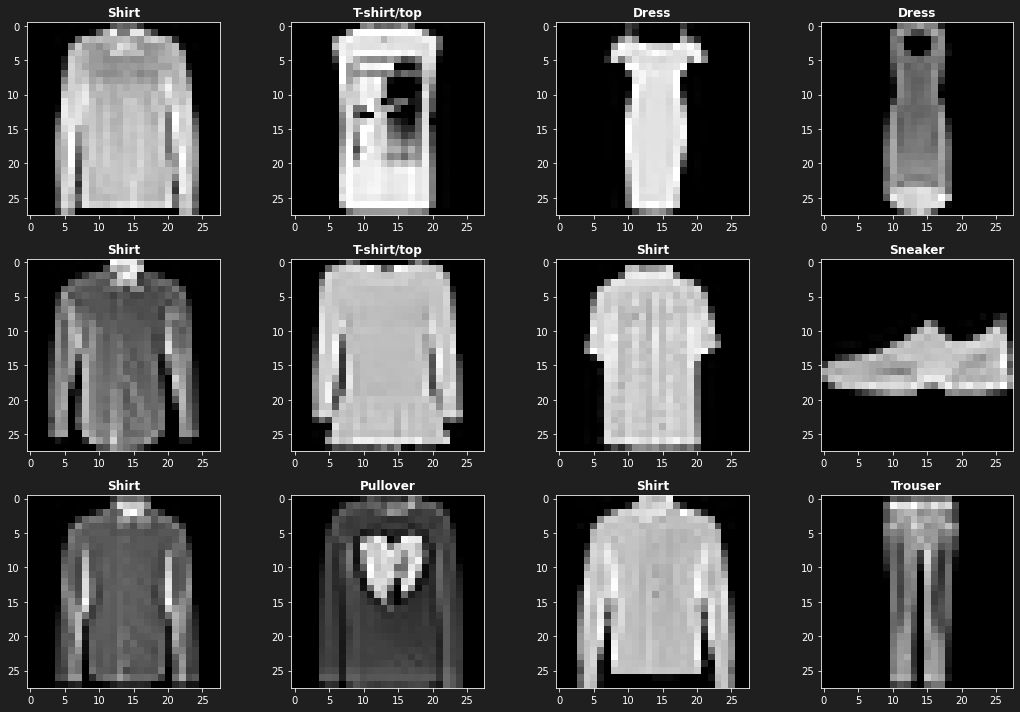

In [6]:
plot_sample(X_train, y_train, labels)

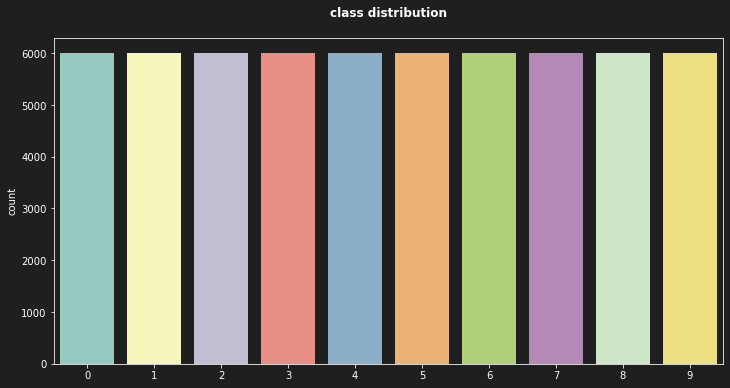

array([6000, 6000, 6000, 6000, 6000, 6000, 6000, 6000, 6000, 6000],
      dtype=int64)

In [7]:
plt.figure(figsize=(12, 6))
plt.title('class distribution\n')
sns.countplot(x=y_train)
plt.show()

_, count = np.unique(y_train, return_counts=True)
count

In [8]:
model = get_model(np.unique(y_train).shape[0])

model.fit(X_train, y_train, epochs=20,
          batch_size=100, validation_split=0.2)

Epoch 1/20
480/480 [==============================] - 3s 2ms/step - loss: 3.9926 - accuracy: 0.7256 - val_loss: 1.0514 - val_accuracy: 0.7622
Epoch 2/20
480/480 [==============================] - 1s 2ms/step - loss: 0.8064 - accuracy: 0.7863 - val_loss: 0.6977 - val_accuracy: 0.7994
Epoch 3/20
480/480 [==============================] - 1s 2ms/step - loss: 0.6058 - accuracy: 0.8098 - val_loss: 0.5944 - val_accuracy: 0.8148
Epoch 4/20
480/480 [==============================] - 1s 2ms/step - loss: 0.5242 - accuracy: 0.8278 - val_loss: 0.5463 - val_accuracy: 0.8274
Epoch 5/20
480/480 [==============================] - 1s 2ms/step - loss: 0.4757 - accuracy: 0.8364 - val_loss: 0.5713 - val_accuracy: 0.8217
Epoch 6/20
480/480 [==============================] - 1s 2ms/step - loss: 0.4407 - accuracy: 0.8460 - val_loss: 0.5218 - val_accuracy: 0.8283
Epoch 7/20
480/480 [==============================] - 1s 3ms/step - loss: 0.4402 - accuracy: 0.8460 - val_loss: 0.5392 - val_accuracy: 0.8344
Epoch 

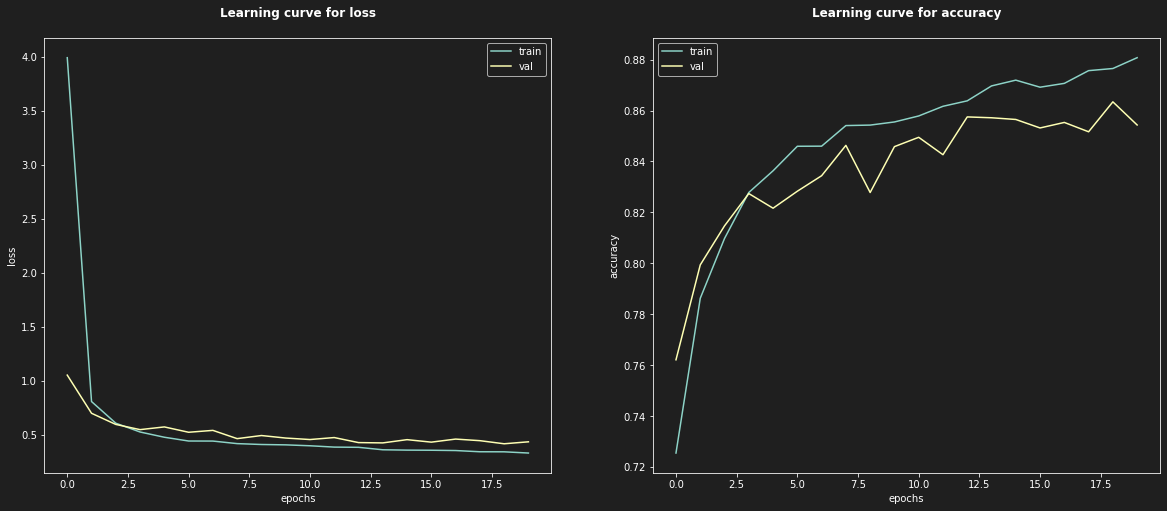

In [9]:
plot_lc(model.history.history)

In [10]:
y_pred = np.argmax(model.predict(X_test), axis=1)

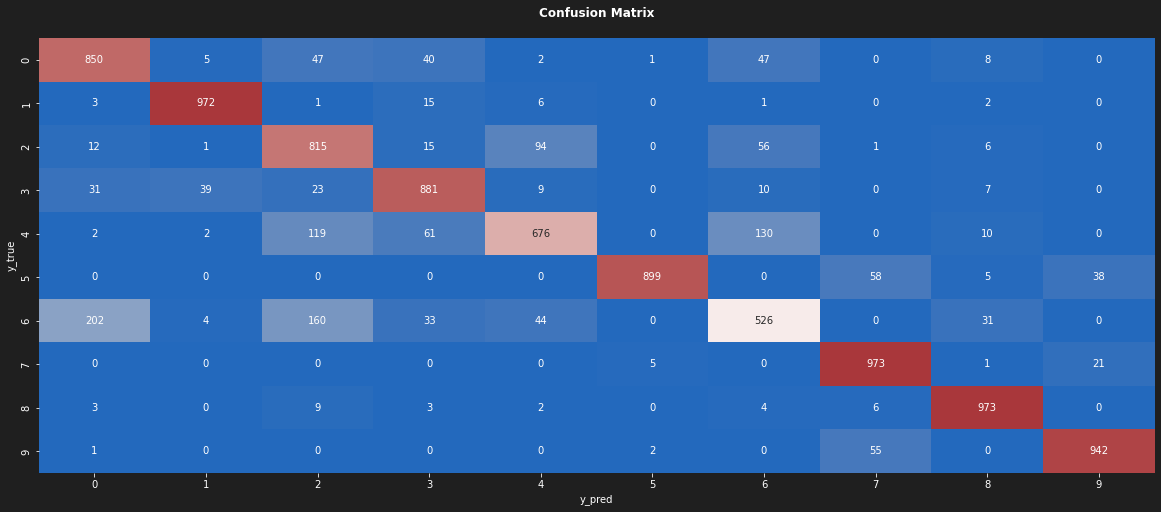

              precision    recall  f1-score   support

           0       0.77      0.85      0.81      1000
           1       0.95      0.97      0.96      1000
           2       0.69      0.81      0.75      1000
           3       0.84      0.88      0.86      1000
           4       0.81      0.68      0.74      1000
           5       0.99      0.90      0.94      1000
           6       0.68      0.53      0.59      1000
           7       0.89      0.97      0.93      1000
           8       0.93      0.97      0.95      1000
           9       0.94      0.94      0.94      1000

    accuracy                           0.85     10000
   macro avg       0.85      0.85      0.85     10000
weighted avg       0.85      0.85      0.85     10000



In [11]:
plot_cm(y_test, y_pred)
print(classification_report(y_test, y_pred))